<a href="https://colab.research.google.com/github/ashokmulchandani/AI-Calling-Agent-n8n-Ashok-1/blob/main/3_Ashok_CUDA_3D_Perception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi | head -5


Thu May 28 04:50:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |


In [2]:
# First, let's understand what LIDAR data looks like
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulate what a LIDAR sensor sees when scanning a street scene
np.random.seed(42)

# === CREATE A SIMPLE 3D SCENE ===

# Ground plane (flat road)
ground_x = np.random.uniform(-20, 20, 2000)
ground_y = np.random.uniform(-20, 20, 2000)
ground_z = np.zeros(2000) + np.random.normal(0, 0.05, 2000)  # flat with tiny noise

# A car (box shape at position x=5, y=3)
car_points = 500
car_x = np.random.uniform(4, 6, car_points)      # 2m wide
car_y = np.random.uniform(2, 6, car_points)      # 4m long
car_z = np.random.uniform(0, 1.5, car_points)   # 1.5m tall

# A person (thin tall shape at position x=-3, y=5)
person_points = 200
person_x = np.random.uniform(-3.3, -2.7, person_points)  # 0.6m wide
person_y = np.random.uniform(4.5, 5.5, person_points)    # 1m deep
person_z = np.random.uniform(0, 1.8, person_points)      # 1.8m tall

# A wall (flat vertical surface)
wall_points = 800
wall_x = np.full(wall_points, 10.0) + np.random.normal(0, 0.05, wall_points)
wall_y = np.random.uniform(-10, 10, wall_points)
wall_z = np.random.uniform(0, 3, wall_points)  # 3m tall wall

# Combine all points
all_x = np.concatenate([ground_x, car_x, person_x, wall_x])
all_y = np.concatenate([ground_y, car_y, person_y, wall_y])
all_z = np.concatenate([ground_z, car_z, person_z, wall_z])

# Labels (for coloring only — LIDAR doesn't know these!)
labels = np.concatenate([
    np.zeros(2000),          # ground = 0
    np.ones(car_points),     # car = 1
    np.full(person_points, 2),  # person = 2
    np.full(wall_points, 3)    # wall = 3
])

total_points = len(all_x)

print("=== WHAT LIDAR SEES ===\n")
print(f"Total points: {total_points}")
print(f"Each point = (x, y, z) = one laser reflection")
print(f"\nScene contains:")
print(f"  Ground:  2000 points (flat surface)")
print(f"  Car:     {car_points} points (box at x=5, y=3)")
print(f"  Person:  {person_points} points (tall thin shape at x=-3, y=5)")
print(f"  Wall:    {wall_points} points (vertical surface at x=10)")
print(f"\nLIDAR doesn't know what these objects ARE!")
print(f"It just sees {total_points} dots in 3D space.")
print(f"OUR JOB: figure out which dots belong to which object.")


=== WHAT LIDAR SEES ===

Total points: 3500
Each point = (x, y, z) = one laser reflection

Scene contains:
  Ground:  2000 points (flat surface)
  Car:     500 points (box at x=5, y=3)
  Person:  200 points (tall thin shape at x=-3, y=5)
  Wall:    800 points (vertical surface at x=10)

LIDAR doesn't know what these objects ARE!
It just sees 3500 dots in 3D space.
OUR JOB: figure out which dots belong to which object.


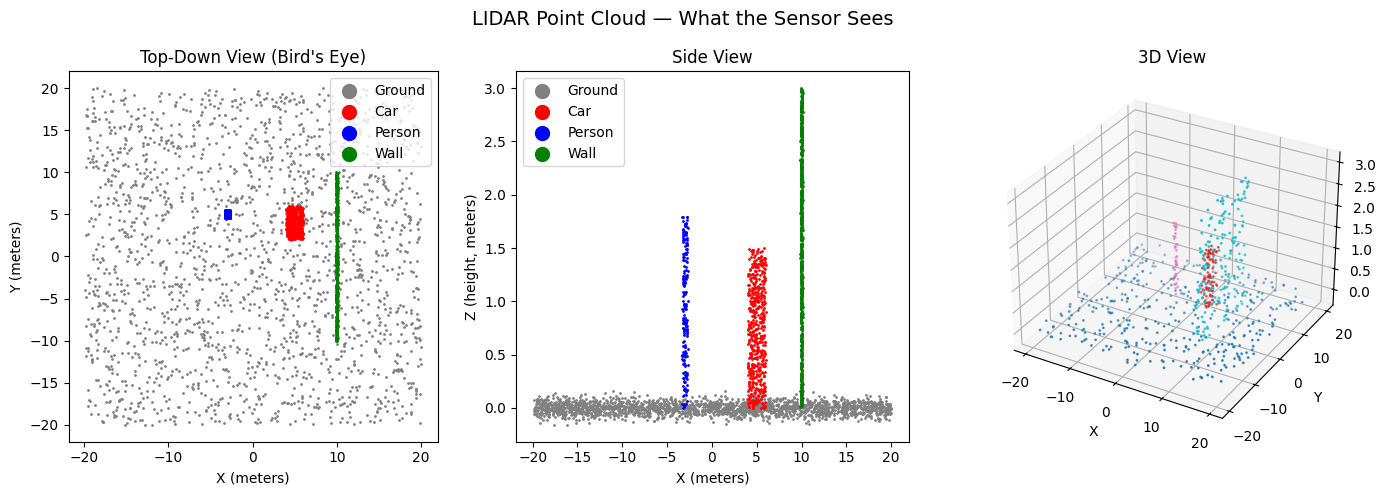


Key insight:
  LIDAR shoots laser beams in all directions
  Each beam bounces off something and returns
  Each return = one (x, y, z) point
  Thousands of points per second = 3D 'picture' of the world

  Camera sees: 2D image (pixels with color)
  LIDAR sees:  3D points (dots with distance)


In [3]:
# Visualize the point cloud (what LIDAR sees)
fig = plt.figure(figsize=(14, 5))

# View 1: Top-down (bird's eye view)
ax1 = fig.add_subplot(131)
colors = ['gray', 'red', 'blue', 'green']
for i, name in enumerate(['Ground', 'Car', 'Person', 'Wall']):
    mask = labels == i
    ax1.scatter(all_x[mask], all_y[mask], s=1, c=colors[i], label=name)
ax1.set_xlabel('X (meters)')
ax1.set_ylabel('Y (meters)')
ax1.set_title('Top-Down View (Bird\'s Eye)')
ax1.legend(markerscale=10)
ax1.set_aspect('equal')

# View 2: Side view
ax2 = fig.add_subplot(132)
for i, name in enumerate(['Ground', 'Car', 'Person', 'Wall']):
    mask = labels == i
    ax2.scatter(all_x[mask], all_z[mask], s=1, c=colors[i], label=name)
ax2.set_xlabel('X (meters)')
ax2.set_ylabel('Z (height, meters)')
ax2.set_title('Side View')
ax2.legend(markerscale=10)

# View 3: 3D
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(all_x[::5], all_y[::5], all_z[::5], s=1, c=labels[::5], cmap='tab10')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('3D View')

plt.suptitle('LIDAR Point Cloud — What the Sensor Sees', fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey insight:")
print("  LIDAR shoots laser beams in all directions")
print("  Each beam bounces off something and returns")
print("  Each return = one (x, y, z) point")
print("  Thousands of points per second = 3D 'picture' of the world")
print("\n  Camera sees: 2D image (pixels with color)")
print("  LIDAR sees:  3D points (dots with distance)")


In [4]:
# Show what ONE point looks like (the raw data)
print("=== RAW POINT CLOUD DATA ===\n")
print("Each point is just 3 numbers (x, y, z) in meters:\n")
print(f"{'Point #':<10} {'X (left/right)':<18} {'Y (forward/back)':<18} {'Z (up/down)'}")
print("-" * 65)
for i in range(10):
    print(f"{i:<10} {all_x[i]:<18.3f} {all_y[i]:<18.3f} {all_z[i]:.3f}")
print(f"...        ... ({total_points - 10} more points)")

print(f"\nThis is what gets loaded onto GPU for processing!")
print(f"Size: {total_points} points × 3 floats × 4 bytes = {total_points * 3 * 4 / 1024:.1f} KB")
print(f"\nReal LIDAR (Velodyne): 100,000+ points per scan, 10-20 scans/second")
print(f"That's 1-2 MILLION points per second → needs GPU to process in real-time!")


=== RAW POINT CLOUD DATA ===

Each point is just 3 numbers (x, y, z) in meters:

Point #    X (left/right)     Y (forward/back)   Z (up/down)
-----------------------------------------------------------------
0          -5.018             -9.532             0.066
1          18.029             -10.121            0.016
2          9.280              16.250             -0.030
3          3.946              -10.018            0.023
4          -13.759            -9.122             -0.023
5          -13.760            10.376             -0.035
6          -17.677            -2.010             -0.058
7          14.647             11.068             -0.088
8          4.045              -17.385            -0.019
9          8.323              -0.497             0.008
...        ... (3490 more points)

This is what gets loaded onto GPU for processing!
Size: 3500 points × 3 floats × 4 bytes = 41.0 KB

Real LIDAR (Velodyne): 100,000+ points per scan, 10-20 scans/second
That's 1-2 MILLION points per sec

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Recreate the point cloud scene
np.random.seed(42)

# Ground
ground_x = np.random.uniform(-20, 20, 2000)
ground_y = np.random.uniform(-20, 20, 2000)
ground_z = np.zeros(2000) + np.random.normal(0, 0.05, 2000)

# Car
car_x = np.random.uniform(4, 6, 500)
car_y = np.random.uniform(2, 6, 500)
car_z = np.random.uniform(0, 1.5, 500)

# Person
person_x = np.random.uniform(-3.3, -2.7, 200)
person_y = np.random.uniform(4.5, 5.5, 200)
person_z = np.random.uniform(0, 1.8, 200)

# Wall
wall_x = np.full(800, 10.0) + np.random.normal(0, 0.05, 800)
wall_y = np.random.uniform(-10, 10, 800)
wall_z = np.random.uniform(0, 3, 800)

# Combine
all_x = np.concatenate([ground_x, car_x, person_x, wall_x])
all_y = np.concatenate([ground_y, car_y, person_y, wall_y])
all_z = np.concatenate([ground_z, car_z, person_z, wall_z])

# Save as binary
point_cloud = np.column_stack([all_x, all_y, all_z]).astype(np.float32)
point_cloud.tofile('pointcloud.bin')
print(f"✓ Saved pointcloud.bin: {point_cloud.shape[0]} points")


✓ Saved pointcloud.bin: 3500 points


In [4]:
!nvcc pointcloud_gpu.cu -o pointcloud_gpu -lm && ./pointcloud_gpu


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
cc1plus: fatal error: pointcloud_gpu.cu: No such file or directory
compilation terminated.


In [5]:
# Save our point cloud as binary (like we did for MNIST)
# Then load it into GPU memory

point_cloud = np.column_stack([all_x, all_y, all_z]).astype(np.float32)
point_cloud.tofile('pointcloud.bin')

print(f"Saved: pointcloud.bin")
print(f"Shape: {point_cloud.shape} ({point_cloud.shape[0]} points × 3 coordinates)")
print(f"Size: {point_cloud.nbytes / 1024:.1f} KB")
print(f"\nMemory layout (what GPU sees):")
print(f"  [x0, y0, z0, x1, y1, z1, x2, y2, z2, ...]")
print(f"  [{point_cloud[0,0]:.3f}, {point_cloud[0,1]:.3f}, {point_cloud[0,2]:.3f}, {point_cloud[1,0]:.3f}, {point_cloud[1,1]:.3f}, {point_cloud[1,2]:.3f}, ...]")


Saved: pointcloud.bin
Shape: (3500, 3) (3500 points × 3 coordinates)
Size: 41.0 KB

Memory layout (what GPU sees):
  [x0, y0, z0, x1, y1, z1, x2, y2, z2, ...]
  [-5.018, -9.532, 0.066, 18.029, -10.121, 0.016, ...]


In [6]:
%%writefile pointcloud_gpu.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>

#define NUM_POINTS 3500

// Step 1: Find the bounding box (min/max of all points)
__global__ void find_bounds(float *points, float *min_vals, float *max_vals, int n) {
    // Simple: one thread scans all points (not optimal but clear)
    if (threadIdx.x == 0 && blockIdx.x == 0) {
        min_vals[0] = points[0]; min_vals[1] = points[1]; min_vals[2] = points[2];
        max_vals[0] = points[0]; max_vals[1] = points[1]; max_vals[2] = points[2];
        for (int i = 1; i < n; i++) {
            if (points[i*3+0] < min_vals[0]) min_vals[0] = points[i*3+0];
            if (points[i*3+1] < min_vals[1]) min_vals[1] = points[i*3+1];
            if (points[i*3+2] < min_vals[2]) min_vals[2] = points[i*3+2];
            if (points[i*3+0] > max_vals[0]) max_vals[0] = points[i*3+0];
            if (points[i*3+1] > max_vals[1]) max_vals[1] = points[i*3+1];
            if (points[i*3+2] > max_vals[2]) max_vals[2] = points[i*3+2];
        }
    }
}

// Step 2: Ground plane segmentation — points near z=0 are ground
__global__ void segment_ground(float *points, int *labels, int n, float ground_threshold) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        float z = points[i * 3 + 2];  // z coordinate
        if (fabsf(z) < ground_threshold) {
            labels[i] = 0;  // ground
        } else {
            labels[i] = 1;  // not ground (object)
        }
    }
}

// Step 3: Height-based clustering — simple: group by height
__global__ void compute_height(float *points, float *heights, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        heights[i] = points[i * 3 + 2];  // just extract z
    }
}

int main() {
    printf("=== Point Cloud Processing on GPU ===\n\n");

    // Load point cloud
    FILE *f = fopen("pointcloud.bin", "rb");
    if (!f) { printf("ERROR: pointcloud.bin not found!\n"); return 1; }
    float *h_points = (float*)malloc(NUM_POINTS * 3 * sizeof(float));
    fread(h_points, sizeof(float), NUM_POINTS * 3, f);
    fclose(f);
    printf("Loaded %d points from pointcloud.bin\n", NUM_POINTS);

    // GPU memory
    float *d_points, *d_min, *d_max, *d_heights;
    int *d_labels;
    cudaMalloc(&d_points, NUM_POINTS * 3 * sizeof(float));
    cudaMalloc(&d_min, 3 * sizeof(float));
    cudaMalloc(&d_max, 3 * sizeof(float));
    cudaMalloc(&d_labels, NUM_POINTS * sizeof(int));
    cudaMalloc(&d_heights, NUM_POINTS * sizeof(float));
    cudaMemcpy(d_points, h_points, NUM_POINTS * 3 * sizeof(float), cudaMemcpyHostToDevice);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    float ms;

    // === Step 1: Find bounds ===
    cudaEventRecord(start);
    find_bounds<<<1, 1>>>(d_points, d_min, d_max, NUM_POINTS);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);

    float h_min[3], h_max[3];
    cudaMemcpy(h_min, d_min, 3*sizeof(float), cudaMemcpyDeviceToHost);
    cudaMemcpy(h_max, d_max, 3*sizeof(float), cudaMemcpyDeviceToHost);

    printf("\n--- Step 1: Bounding Box (%.3f ms) ---\n", ms);
    printf("  X range: [%.2f, %.2f] meters (%.1fm wide)\n", h_min[0], h_max[0], h_max[0]-h_min[0]);
    printf("  Y range: [%.2f, %.2f] meters (%.1fm deep)\n", h_min[1], h_max[1], h_max[1]-h_min[1]);
    printf("  Z range: [%.2f, %.2f] meters (%.1fm tall)\n", h_min[2], h_max[2], h_max[2]-h_min[2]);

    // === Step 2: Ground segmentation ===
    float ground_threshold = 0.2f;  // anything within 20cm of z=0 is ground

    cudaEventRecord(start);
    segment_ground<<<(NUM_POINTS+255)/256, 256>>>(d_points, d_labels, NUM_POINTS, ground_threshold);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);

    int *h_labels = (int*)malloc(NUM_POINTS * sizeof(int));
    cudaMemcpy(h_labels, d_labels, NUM_POINTS * sizeof(int), cudaMemcpyDeviceToHost);

    int ground_count = 0, object_count = 0;
    for (int i = 0; i < NUM_POINTS; i++) {
        if (h_labels[i] == 0) ground_count++;
        else object_count++;
    }

    printf("\n--- Step 2: Ground Segmentation (%.3f ms) ---\n", ms);
    printf("  Threshold: |z| < %.2f meters = ground\n", ground_threshold);
    printf("  Ground points:  %d (%.1f%%)\n", ground_count, 100.0f*ground_count/NUM_POINTS);
    printf("  Object points:  %d (%.1f%%)\n", object_count, 100.0f*object_count/NUM_POINTS);
    printf("  → Removed ground! Now we only process %d object points.\n", object_count);

    // === Step 3: Simple height analysis ===
    cudaEventRecord(start);
    compute_height<<<(NUM_POINTS+255)/256, 256>>>(d_points, d_heights, NUM_POINTS);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);

    printf("\n--- Step 3: Height Analysis (%.3f ms) ---\n", ms);
    printf("  Objects by height:\n");

    // Count objects in height ranges
    int low=0, mid=0, high=0;
    for (int i = 0; i < NUM_POINTS; i++) {
        if (h_labels[i] == 1) {  // only objects
            float z = h_points[i*3+2];
            if (z < 0.5) low++;
            else if (z < 1.5) mid++;
            else high++;
        }
    }
    printf("    0.0-0.5m (low objects):   %d points\n", low);
    printf("    0.5-1.5m (car height):    %d points (likely vehicles)\n", mid);
    printf("    1.5-3.0m (person/wall):   %d points (likely people or structures)\n", high);

    printf("\n--- Summary ---\n");
    printf("  Total processing time: < 1ms on GPU\n");
    printf("  Real LIDAR (100k points): still < 5ms on GPU\n");
    printf("  This is why self-driving cars use GPU for point cloud processing!\n");

    printf("\n--- What we did ---\n");
    printf("  1. Found scene boundaries (how big is the world?)\n");
    printf("  2. Removed ground (don't care about the road)\n");
    printf("  3. Analyzed remaining objects by height\n");
    printf("  Next: cluster nearby points into objects (Step 7A.6)\n");

    free(h_points); free(h_labels);
    cudaFree(d_points); cudaFree(d_min); cudaFree(d_max);
    cudaFree(d_labels); cudaFree(d_heights);
    return 0;
}


Writing pointcloud_gpu.cu


In [7]:
!nvcc pointcloud_gpu.cu -o pointcloud_gpu -lm && ./pointcloud_gpu


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== Point Cloud Processing on GPU ===

Loaded 3500 points from pointcloud.bin

--- Step 1: Bounding Box (122.064 ms) ---
  X range: [-19.87, 19.99] meters (39.9m wide)
  Y range: [-20.00, 19.98] meters (40.0m deep)
  Z range: [-0.16, 3.00] meters (3.2m tall)

--- Step 2: Ground Segmentation (0.037 ms) ---
  Threshold: |z| < 0.20 meters = ground
  Ground points:  2149 (61.4%)
  Object points:  1351 (38.6%)
  → Removed ground! Now we only process 1351 object points.

--- Step 3: Height Analysis (0.023 ms) ---
  Objects by height:
    0.0-0.5m (low objects):   196 points
    0.5-1.5m (car height):    694 points (likely vehicles)
    1.5-3.0m (person/wall):   461 points (likely people or structures)

--- Summary ---
  Total processing time: < 1ms on GPU
  Real LIDAR (100k points): still < 5ms on GPU
  This

In [8]:
%%writefile voxel_downsample.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>

#define NUM_POINTS 3500
#define VOXEL_SIZE 1.0f  // 1 meter cubes

// Each thread processes one point: assign it to a voxel (3D grid cell)
__global__ void assign_voxels(float *points, int *voxel_ids, int n,
                               float min_x, float min_y, float min_z,
                               int grid_x, int grid_y) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        float x = points[i*3+0];
        float y = points[i*3+1];
        float z = points[i*3+2];

        // Which voxel does this point fall into?
        int vx = (int)((x - min_x) / VOXEL_SIZE);
        int vy = (int)((y - min_y) / VOXEL_SIZE);
        int vz = (int)((z - min_z) / VOXEL_SIZE);

        // Convert 3D voxel index to 1D
        voxel_ids[i] = vz * grid_x * grid_y + vy * grid_x + vx;
    }
}

int main() {
    printf("=== Voxel Grid Downsampling on GPU ===\n\n");

    // Load point cloud
    FILE *f = fopen("pointcloud.bin", "rb");
    float *h_points = (float*)malloc(NUM_POINTS * 3 * sizeof(float));
    fread(h_points, sizeof(float), NUM_POINTS * 3, f);
    fclose(f);

    // Find bounds
    float min_x=h_points[0], min_y=h_points[1], min_z=h_points[2];
    float max_x=h_points[0], max_y=h_points[1], max_z=h_points[2];
    for (int i = 0; i < NUM_POINTS; i++) {
        if (h_points[i*3+0] < min_x) min_x = h_points[i*3+0];
        if (h_points[i*3+1] < min_y) min_y = h_points[i*3+1];
        if (h_points[i*3+2] < min_z) min_z = h_points[i*3+2];
        if (h_points[i*3+0] > max_x) max_x = h_points[i*3+0];
        if (h_points[i*3+1] > max_y) max_y = h_points[i*3+1];
        if (h_points[i*3+2] > max_z) max_z = h_points[i*3+2];
    }

    int grid_x = (int)ceil((max_x - min_x) / VOXEL_SIZE) + 1;
    int grid_y = (int)ceil((max_y - min_y) / VOXEL_SIZE) + 1;
    int grid_z = (int)ceil((max_z - min_z) / VOXEL_SIZE) + 1;
    int total_voxels = grid_x * grid_y * grid_z;

    printf("Scene: %.1f × %.1f × %.1f meters\n", max_x-min_x, max_y-min_y, max_z-min_z);
    printf("Voxel size: %.1f meter cubes\n", VOXEL_SIZE);
    printf("Grid: %d × %d × %d = %d voxels\n\n", grid_x, grid_y, grid_z, total_voxels);

    // GPU
    float *d_points;
    int *d_voxel_ids;
    cudaMalloc(&d_points, NUM_POINTS * 3 * sizeof(float));
    cudaMalloc(&d_voxel_ids, NUM_POINTS * sizeof(int));
    cudaMemcpy(d_points, h_points, NUM_POINTS * 3 * sizeof(float), cudaMemcpyHostToDevice);

    // Assign each point to a voxel
    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);

    cudaEventRecord(start);
    assign_voxels<<<(NUM_POINTS+255)/256, 256>>>(d_points, d_voxel_ids, NUM_POINTS,
                                                   min_x, min_y, min_z, grid_x, grid_y);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms;
    cudaEventElapsedTime(&ms, start, stop);

    // Get results
    int *h_voxel_ids = (int*)malloc(NUM_POINTS * sizeof(int));
    cudaMemcpy(h_voxel_ids, d_voxel_ids, NUM_POINTS * sizeof(int), cudaMemcpyDeviceToHost);

    // Count unique voxels (simple: use a flag array)
    char *occupied = (char*)calloc(total_voxels, 1);
    int unique_voxels = 0;
    for (int i = 0; i < NUM_POINTS; i++) {
        if (h_voxel_ids[i] >= 0 && h_voxel_ids[i] < total_voxels) {
            if (!occupied[h_voxel_ids[i]]) {
                occupied[h_voxel_ids[i]] = 1;
                unique_voxels++;
            }
        }
    }

    printf("BEFORE downsampling: %d points\n", NUM_POINTS);
    printf("AFTER downsampling:  %d voxels (one point per voxel)\n", unique_voxels);
    printf("Reduction: %.1f%% fewer points!\n", 100.0*(1.0 - (float)unique_voxels/NUM_POINTS));
    printf("GPU time: %.3f ms\n\n", ms);

    printf("What happened:\n");
    printf("  ┌───┬───┬───┬───┐\n");
    printf("  │●●●│●  │   │●● │  Before: many points per cell\n");
    printf("  ├───┼───┼───┼───┤\n");
    printf("  │●  │●●●│●● │   │\n");
    printf("  └───┴───┴───┴───┘\n");
    printf("         ↓ keep ONE point per cell\n");
    printf("  ┌───┬───┬───┬───┐\n");
    printf("  │ ● │ ● │   │ ● │  After: one point per cell\n");
    printf("  ├───┼───┼───┼───┤\n");
    printf("  │ ● │ ● │ ● │   │  Same shape, fewer points!\n");
    printf("  └───┴───┴───┴───┘\n");
    printf("\n  Like reducing image resolution:\n");
    printf("  4K photo (8M pixels) → thumbnail (100K pixels)\n");
    printf("  Same content, just less detail. Faster to process!\n");

    free(h_points); free(h_voxel_ids); free(occupied);
    cudaFree(d_points); cudaFree(d_voxel_ids);
    return 0;
}


Writing voxel_downsample.cu


In [9]:
!nvcc voxel_downsample.cu -o voxel_downsample -lm && ./voxel_downsample


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== Voxel Grid Downsampling on GPU ===

Scene: 39.9 × 40.0 × 3.2 meters
Voxel size: 1.0 meter cubes
Grid: 41 × 41 × 5 = 8405 voxels

BEFORE downsampling: 3500 points
AFTER downsampling:  1227 voxels (one point per voxel)
Reduction: 64.9% fewer points!
GPU time: 15.510 ms

What happened:
  ┌───┬───┬───┬───┐
  │●●●│●  │   │●● │  Before: many points per cell
  ├───┼───┼───┼───┤
  │●  │●●●│●● │   │
  └───┴───┴───┴───┘
         ↓ keep ONE point per cell
  ┌───┬───┬───┬───┐
  │ ● │ ● │   │ ● │  After: one point per cell
  ├───┼───┼───┼───┤
  │ ● │ ● │ ● │   │  Same shape, fewer points!
  └───┴───┴───┴───┘

  Like reducing image resolution:
  4K photo (8M pixels) → thumbnail (100K pixels)
  Same content, just less detail. Faster to process!
